In [30]:
import os
import csv
import json
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

PROJECT = r"C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project"
TAGS = ["L1000765", "L1000766", "L1000767", "L1000768"]
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Load all reference card crops AND their aligned masks, keyed by card label.
# card_images[label][i] and card_masks[label][i] correspond to the same source crop.
ref_labels = {}
with open(os.path.join(PROJECT, "reference.csv"), newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        img_id = row["image_id"].strip()
        card   = row["card"].strip()
        if img_id:
            ref_labels[img_id] = card

card_images = {}   # label -> [BGR ndarray, ...]
card_masks  = {}   # label -> [grayscale ndarray (0/255), ...] — same indices as card_images

for tag in TAGS:
    crops_dir  = os.path.join(PROJECT, tag, f"crops_{tag}")
    closed_dir = os.path.join(PROJECT, tag, f"closed_components_{tag}")
    if not os.path.isdir(crops_dir):
        continue

    for fname in sorted(os.listdir(crops_dir)):
        if not fname.lower().endswith(".jpg"):
            continue
        idx     = fname.replace("crop_", "").replace(".jpg", "")
        base_id = f"{tag}_crop_{idx}"
        label   = ref_labels.get(base_id)
        if label is None:
            continue

        img = cv2.imread(os.path.join(crops_dir, fname), cv2.IMREAD_COLOR)
        if img is None:
            continue

        # Load the corresponding closed-component mask and align it to crop dims
        mask_path = os.path.join(closed_dir, f"closed_component_{idx}.jpg")
        m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue

        ih, iw = img.shape[:2]
        if np.count_nonzero(m) == 0:
            aligned = np.zeros((ih, iw), dtype=np.uint8)
        else:
            x, y, w, h = cv2.boundingRect(m)
            if w > 0 and h > 0:
                mc = m[y:y+h, x:x+w]
                if mc.shape[:2] != (ih, iw):
                    mc = cv2.resize(mc, (iw, ih), interpolation=cv2.INTER_NEAREST)
                aligned = (mc > 127).astype(np.uint8) * 255
            else:
                aligned = np.zeros((ih, iw), dtype=np.uint8)

        card_images.setdefault(label, []).append(img)
        card_masks.setdefault(label, []).append(aligned)

all_labels = sorted(card_images.keys())
print(f"Loaded {sum(len(v) for v in card_images.values())} crops "
      f"across {len(all_labels)} card types: {all_labels}")

Loaded 52 crops across 50 card types: ['b_2', 'b_3', 'b_4', 'b_5', 'b_6', 'b_7', 'b_8', 'b_9', 'b_draw_2', 'b_reverse', 'b_skip', 'draw_4', 'g_0', 'g_2', 'g_3', 'g_4', 'g_5', 'g_6', 'g_7', 'g_8', 'g_9', 'g_draw_2', 'g_reverse', 'g_skip', 'r_0', 'r_1', 'r_2', 'r_3', 'r_4', 'r_5', 'r_6', 'r_7', 'r_8', 'r_9', 'r_draw_2', 'r_reverse', 'r_skip', 'wild', 'y_1', 'y_2', 'y_3', 'y_4', 'y_5', 'y_6', 'y_7', 'y_8', 'y_9', 'y_draw_2', 'y_reverse', 'y_skip']


In [31]:
# Background generators

def bg_solid(h, w, rng):
    """Solid colour: white, off-white, or a random muted colour."""
    choice = rng.integers(0, 3)
    if choice == 0:
        return np.full((h, w, 3), 255, dtype=np.uint8)
    elif choice == 1:
        v = int(rng.integers(220, 256))
        offset = rng.integers(-15, 16, size=3)
        colour = np.clip([v, v, v] + offset, 0, 255).astype(np.uint8)
        return np.full((h, w, 3), colour, dtype=np.uint8)
    else:
        colour = rng.integers(80, 220, size=3, dtype=np.uint8)
        return np.full((h, w, 3), colour, dtype=np.uint8)

def bg_gradient(h, w, rng):
    c1 = rng.integers(50, 256, size=3).astype(np.float32)
    c2 = rng.integers(50, 256, size=3).astype(np.float32)
    img = np.zeros((h, w, 3), dtype=np.float32)
    if rng.random() < 0.5:
        for x in range(w):
            img[:, x] = c1 + (c2 - c1) * x / max(1, w - 1)
    else:
        for y in range(h):
            img[y, :] = c1 + (c2 - c1) * y / max(1, h - 1)
    return img.clip(0, 255).astype(np.uint8)

def bg_checkerboard(h, w, rng):
    tile = int(rng.integers(30, 80))
    c1 = rng.integers(30, 256, size=3, dtype=np.uint8)
    c2 = rng.integers(30, 256, size=3, dtype=np.uint8)
    img = np.zeros((h, w, 3), dtype=np.uint8)
    for r in range(0, h, tile):
        for c in range(0, w, tile):
            col = c1 if ((r // tile + c // tile) % 2 == 0) else c2
            img[r:r+tile, c:c+tile] = col
    return img

def bg_stripes(h, w, rng):
    stripe = int(rng.integers(15, 60))
    c1 = rng.integers(30, 256, size=3, dtype=np.uint8)
    c2 = rng.integers(30, 256, size=3, dtype=np.uint8)
    img = np.zeros((h, w, 3), dtype=np.uint8)
    if rng.random() < 0.5:
        for c in range(0, w, stripe * 2):
            img[:, c:c+stripe] = c1
            img[:, c+stripe:c+stripe*2] = c2
    else:
        for r in range(0, h, stripe * 2):
            img[r:r+stripe, :] = c1
            img[r+stripe:r+stripe*2, :] = c2
    return img

def bg_noise(h, w, rng):
    return rng.integers(0, 256, size=(h, w, 3), dtype=np.uint8)

BG_GENERATORS = [bg_solid, bg_gradient, bg_checkerboard, bg_stripes, bg_noise]

def random_background(h, w, rng):
    return BG_GENERATORS[rng.integers(0, len(BG_GENERATORS))](h, w, rng)

print("Background generators ready.")

Background generators ready.


In [32]:
# Scene builder

def make_scene(
    card_images_dict,
    card_masks_dict,
    rng,
    scene_w=1280,
    scene_h=720,
    n_cards_range=(12, 20),
    card_scale_range=(0.10, 0.25),
):
    """
    Returns (scene_bgr, mask_canvas, placements).
    Cards are drawn sequentially so each one fully occludes whatever is beneath it.
    The convex hull of the card silhouette is used for pasting on the scene (no holes),
    while the original silhouette mask is written to mask_canvas.
    """
    canvas      = random_background(scene_h, scene_w, rng)
    mask_canvas = np.zeros((scene_h, scene_w), dtype=np.uint8)

    n_cards = int(rng.integers(*n_cards_range))
    labels  = list(card_images_dict.keys())
    placements = []

    for _ in range(n_cards):
        label    = labels[rng.integers(0, len(labels))]
        card_idx = int(rng.integers(0, len(card_images_dict[label])))
        src_img  = card_images_dict[label][card_idx]
        src_mask = card_masks_dict[label][card_idx]

        # Same scale for image and mask
        target_h = int(rng.uniform(*card_scale_range) * scene_h)
        scale    = target_h / max(1, src_img.shape[0])
        target_w = max(1, int(src_img.shape[1] * scale))

        img_resized  = cv2.resize(src_img,  (target_w, target_h), interpolation=cv2.INTER_AREA)
        mask_resized = cv2.resize(src_mask, (target_w, target_h), interpolation=cv2.INTER_NEAREST)

        # Same rotation for image and mask
        angle   = float(rng.uniform(0, 360))
        rot_mat = cv2.getRotationMatrix2D((target_w / 2, target_h / 2), angle, 1.0)

        img_rot  = cv2.warpAffine(img_resized,  rot_mat, (target_w, target_h),
                                  flags=cv2.INTER_LINEAR,
                                  borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255))
        mask_rot = cv2.warpAffine(mask_resized, rot_mat, (target_w, target_h),
                                  flags=cv2.INTER_NEAREST,
                                  borderMode=cv2.BORDER_CONSTANT, borderValue=0)

        # Build a solid convex-hull footprint so white interior card pixels don't leave holes
        footprint = np.zeros((target_h, target_w), dtype=np.uint8)
        contours, _ = cv2.findContours(mask_rot, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            all_pts = np.concatenate(contours, axis=0)
            hull    = cv2.convexHull(all_pts)
            cv2.fillPoly(footprint, [hull], 255)
        else:
            continue  # no visible card in this placement, skip

        ch, cw = img_rot.shape[:2]

        # Centre-biased position (σ = 20 % of scene size → dense overlap)
        cx_scene = rng.normal(loc=scene_w * 0.50, scale=scene_w * 0.20)
        cy_scene = rng.normal(loc=scene_h * 0.50, scale=scene_h * 0.20)
        x1 = int(cx_scene - cw / 2)
        y1 = int(cy_scene - ch / 2)
        x2 = x1 + cw
        y2 = y1 + ch

        # Clip regions to canvas bounds
        src_x1 = max(0, -x1);  src_y1 = max(0, -y1)
        dst_x1 = max(0,  x1);  dst_y1 = max(0,  y1)
        dst_x2 = min(scene_w, x2)
        dst_y2 = min(scene_h, y2)
        src_x2 = src_x1 + (dst_x2 - dst_x1)
        src_y2 = src_y1 + (dst_y2 - dst_y1)

        if src_x2 <= src_x1 or src_y2 <= src_y1:
            continue

        img_patch       = img_rot [src_y1:src_y2, src_x1:src_x2]
        footprint_patch = footprint[src_y1:src_y2, src_x1:src_x2]

        # Paste scene image using the solid convex hull (no holes inside the card)
        card_pixels = footprint_patch > 127
        canvas[dst_y1:dst_y2, dst_x1:dst_x2][card_pixels] = img_patch[card_pixels]

        # Mask canvas also uses the solid convex hull — guarantees no annuli/holes
        mask_canvas[dst_y1:dst_y2, dst_x1:dst_x2][card_pixels] = 255

        placements.append(dict(
            label=label, card_idx=card_idx,
            x1=dst_x1, y1=dst_y1, x2=dst_x2, y2=dst_y2,
        ))

    return canvas, mask_canvas, placements

print("Scene builder ready.")

Scene builder ready.


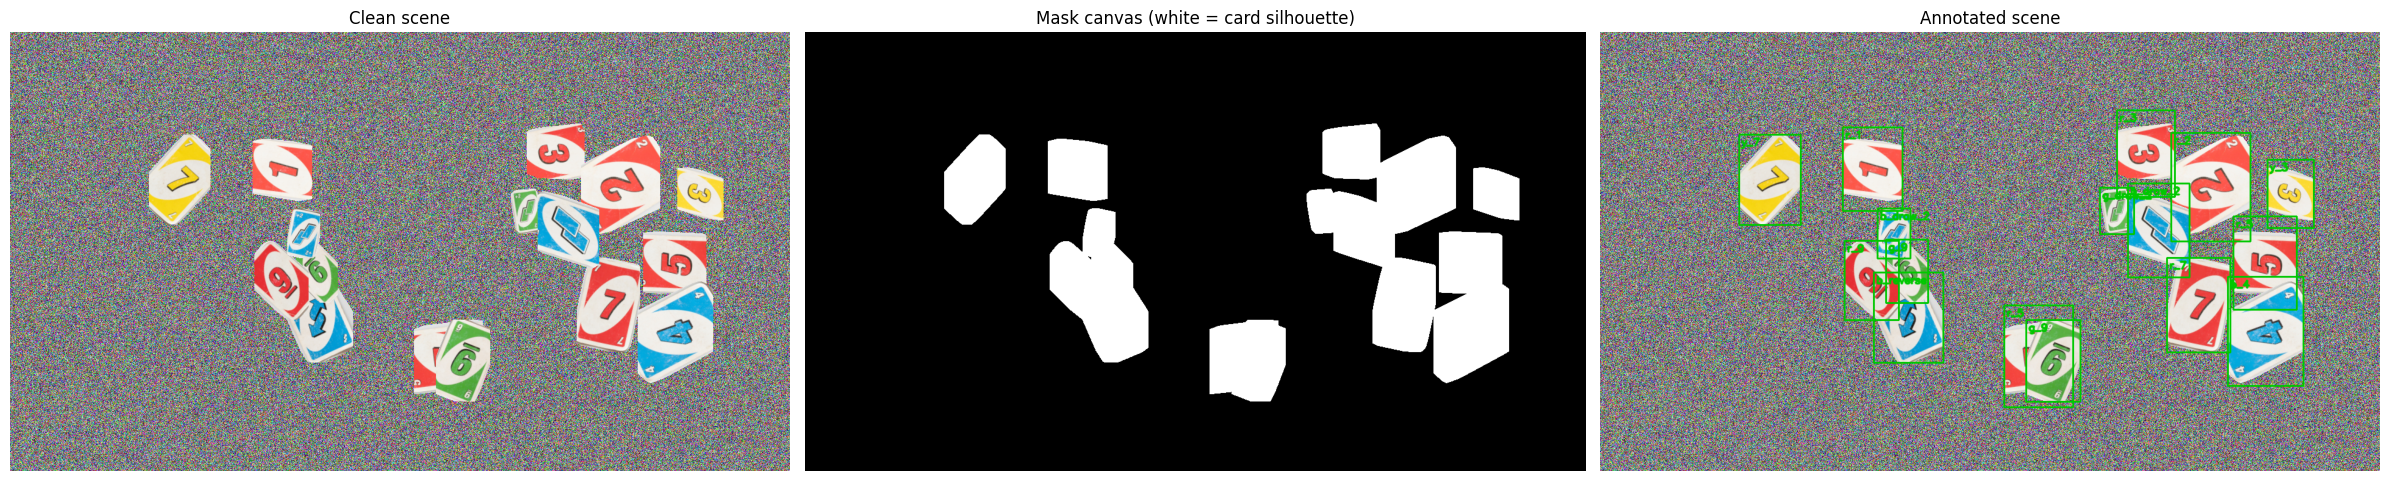

Cards placed: 16
  r_1       bbox=(398,156)-(496,293)
  r_5       bbox=(663,448)-(776,615)
  r_5       bbox=(1039,302)-(1143,455)
  r_3       bbox=(848,128)-(943,270)
  b_reverse  bbox=(449,394)-(563,542)
  g_9       bbox=(469,340)-(538,444)
  y_7       bbox=(228,168)-(329,316)
  g_9       bbox=(699,472)-(788,606)
  r_9       bbox=(401,342)-(490,472)
  r_7       bbox=(930,370)-(1034,525)
  r_2       bbox=(937,165)-(1067,343)
  g_draw_2  bbox=(820,255)-(876,331)
  b_4       bbox=(1030,401)-(1154,580)
  y_3       bbox=(1095,209)-(1171,321)
  b_draw_2  bbox=(866,248)-(967,402)
  b_draw_2  bbox=(455,289)-(509,371)


In [33]:
# Display one example scene + its mask
rng_demo = np.random.default_rng(7)

scene, mask_canvas, placements = make_scene(
    card_images, card_masks, rng_demo, scene_w=1280, scene_h=720
)

# Annotated copy with bounding boxes and labels
vis = scene.copy()
for p in placements:
    cv2.rectangle(vis, (p["x1"], p["y1"]), (p["x2"], p["y2"]), (0, 200, 0), 2)
    cv2.putText(vis, p["label"], (p["x1"] + 4, p["y1"] + 18),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 200, 0), 2, cv2.LINE_AA)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

axes[0].imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
axes[0].set_title("Clean scene")
axes[0].axis("off")

axes[1].imshow(mask_canvas, cmap="gray")
axes[1].set_title("Mask canvas (white = card silhouette)")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[2].set_title("Annotated scene")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Cards placed: {len(placements)}")
for p in placements:
    print(f"  {p['label']:8s}  bbox=({p['x1']},{p['y1']})-({p['x2']},{p['y2']})")

Saved 500 scenes  → C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\game_snapshots\images
Saved 500 masks   → C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\game_snapshots\masks
Saved labels             → C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\game_snapshots\labels.json



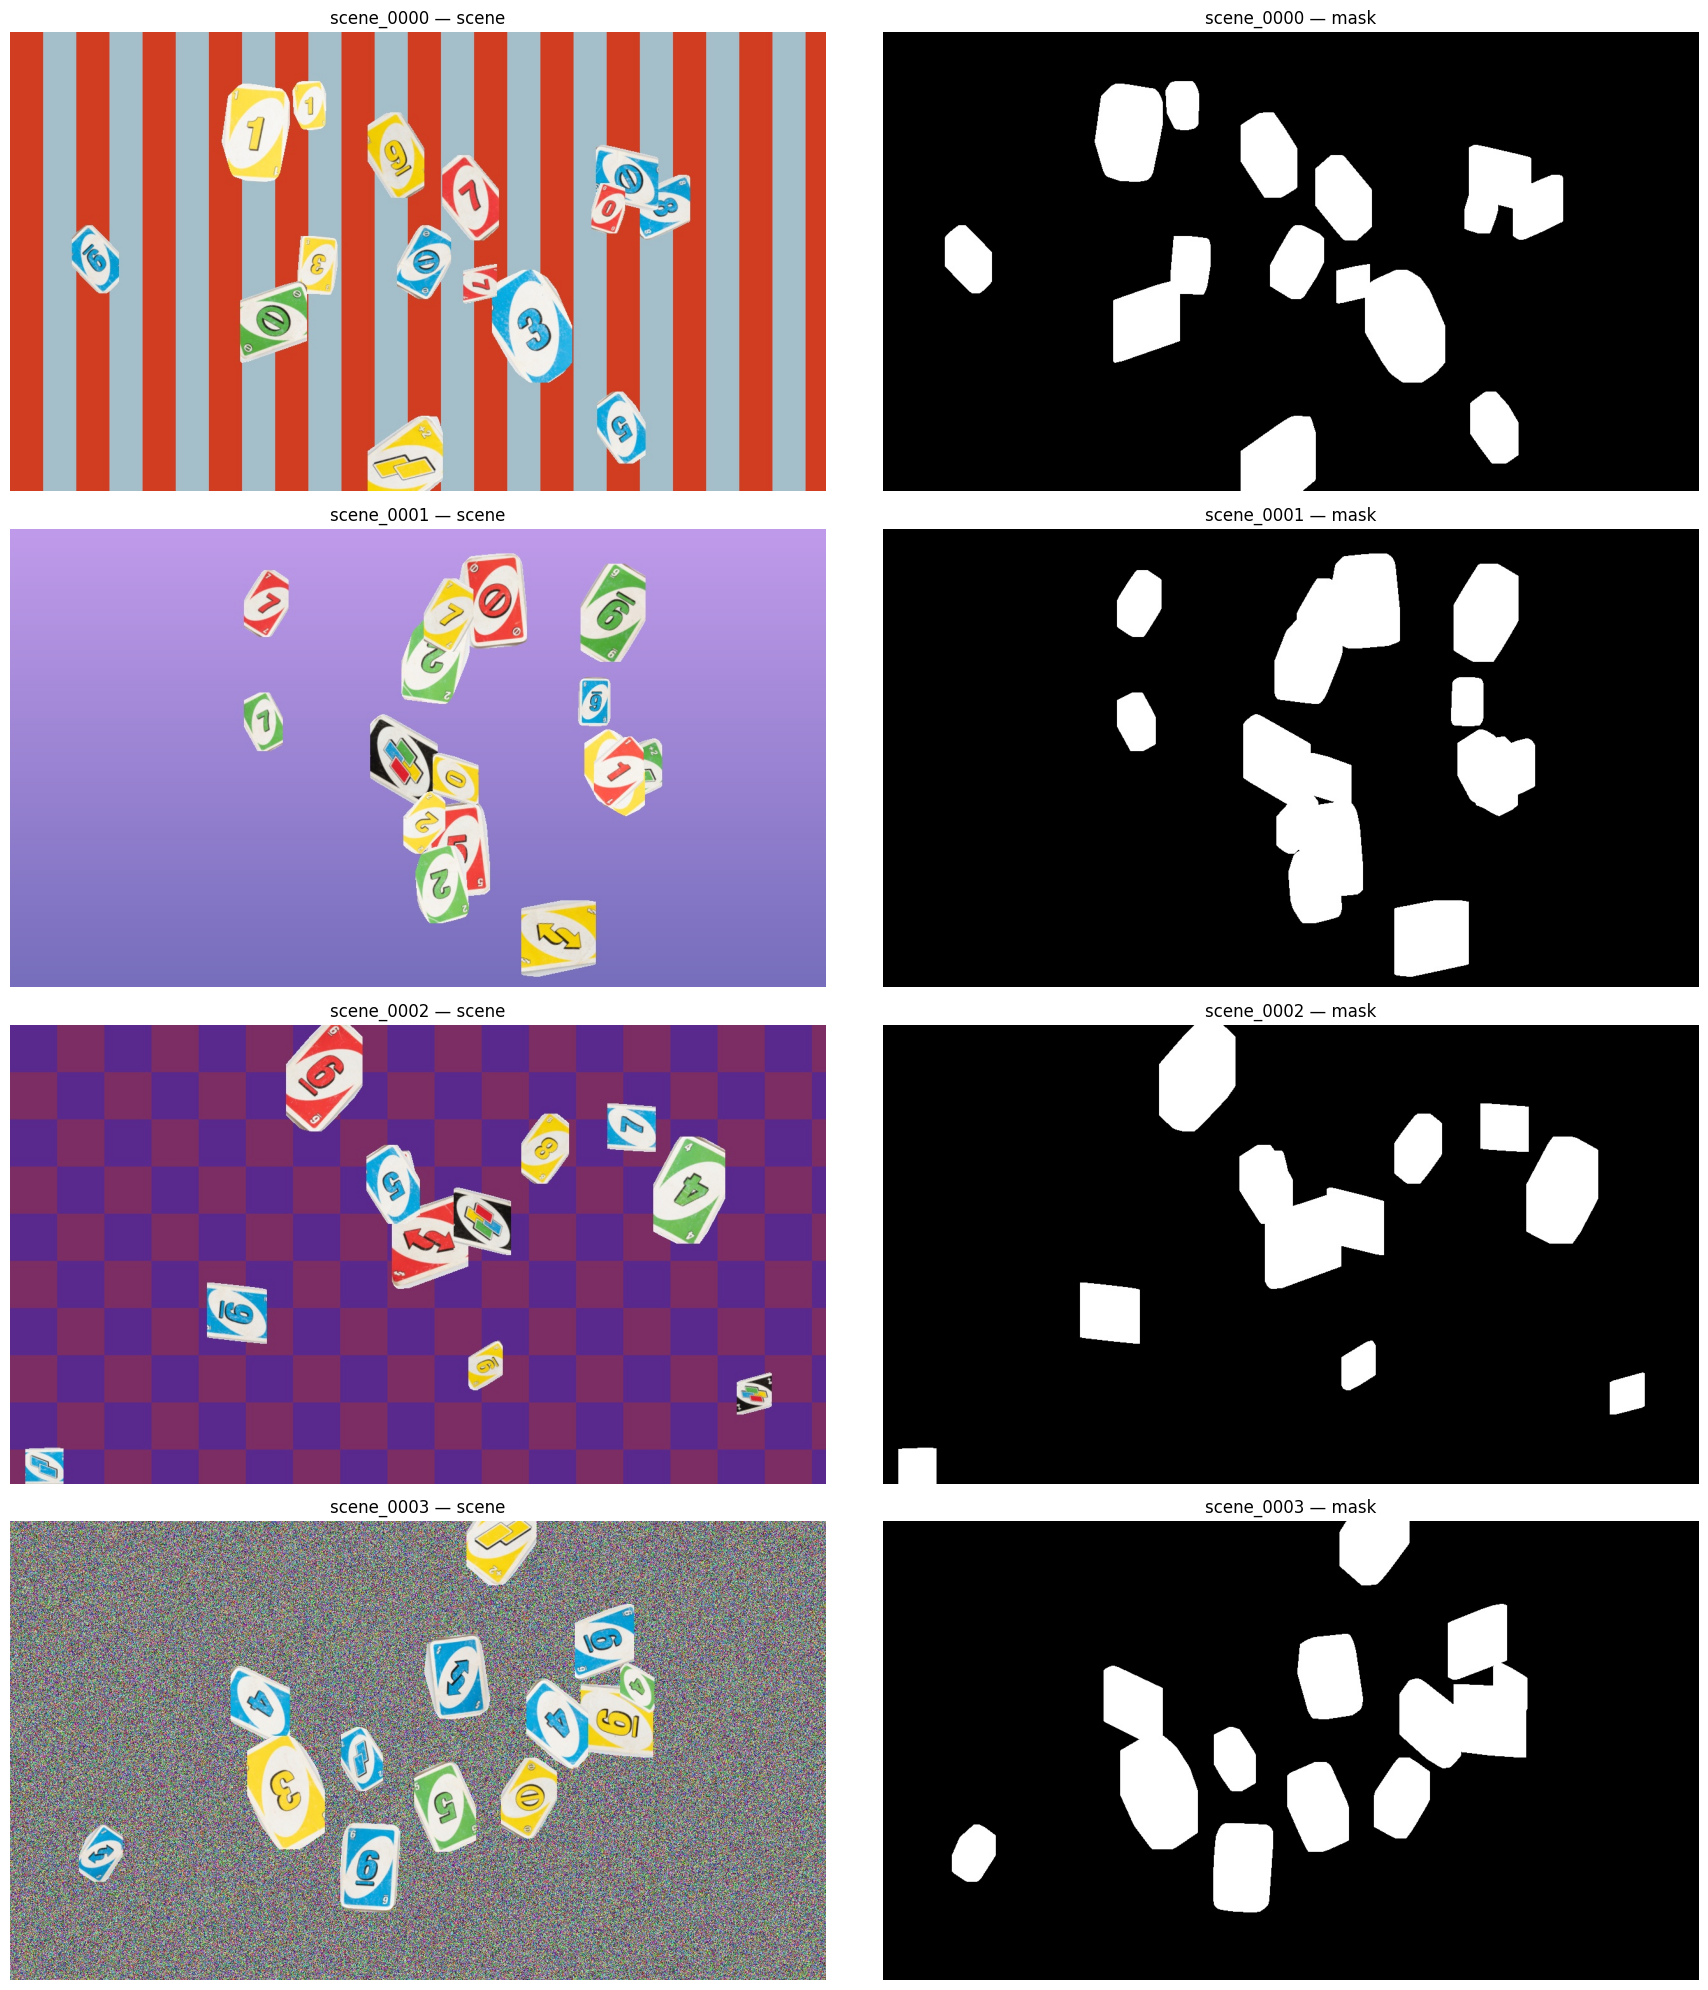

In [34]:
# Generate and save N scenes with matching masks + labels JSON
import json

SAVE_DIR   = os.path.join(PROJECT, "game_snapshots")
N_SCENES   = 500  # change as needed
SCENE_W, SCENE_H = 1280, 720

os.makedirs(os.path.join(SAVE_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "masks"),  exist_ok=True)

rng_save = np.random.default_rng(100)
all_labels_meta = []

for i in range(N_SCENES):
    sc, mc, pl = make_scene(
        card_images, card_masks, rng_save,
        scene_w=SCENE_W, scene_h=SCENE_H,
    )

    scene_name = f"scene_{i:04d}"
    cv2.imwrite(os.path.join(SAVE_DIR, "images", f"{scene_name}.jpg"), sc)
    cv2.imwrite(os.path.join(SAVE_DIR, "masks",  f"{scene_name}.jpg"), mc)

    all_labels_meta.append({
        "scene": scene_name,
        "placements": [
            {"label": p["label"], "x1": p["x1"], "y1": p["y1"], "x2": p["x2"], "y2": p["y2"]}
            for p in pl
        ]
    })

labels_path = os.path.join(SAVE_DIR, "labels.json")
with open(labels_path, "w", encoding="utf-8") as f:
    json.dump(all_labels_meta, f, indent=2)

print(f"Saved {N_SCENES} scenes  → {os.path.join(SAVE_DIR, 'images')}")
print(f"Saved {N_SCENES} masks   → {os.path.join(SAVE_DIR, 'masks')}")
print(f"Saved labels             → {labels_path}")
print()

# Quick visual summary: show 4 random saved scenes + their masks
sample_indices = list(range(min(4, N_SCENES)))
fig, axes = plt.subplots(len(sample_indices), 2, figsize=(18, 5 * len(sample_indices)))
for row, idx in enumerate(sample_indices):
    name = f"scene_{idx:04d}"
    img  = cv2.imread(os.path.join(SAVE_DIR, "images", f"{name}.jpg"))
    msk  = cv2.imread(os.path.join(SAVE_DIR, "masks",  f"{name}.jpg"), cv2.IMREAD_GRAYSCALE)
    axes[row, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"{name} — scene")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(msk, cmap="gray")
    axes[row, 1].set_title(f"{name} — mask")
    axes[row, 1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Add horizontal (±90°) versions of every reference card to card_images / card_masks
added = 0
for label in list(card_images.keys()):
    originals_img  = list(card_images[label])   # snapshot before appending
    originals_mask = list(card_masks[label])

    for img, mask in zip(originals_img, originals_mask):
        for rot_flag in (cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_90_COUNTERCLOCKWISE):
            card_images[label].append(cv2.rotate(img,  rot_flag))
            card_masks[label].append( cv2.rotate(mask, rot_flag))
            added += 1

print(f"Added {added} rotated variants (+90° and -90°).")
print(f"Total crops now: {sum(len(v) for v in card_images.values())} "
      f"across {len(card_images)} card types.")


Added 104 rotated variants (+90° and -90°).
Total crops now: 156 across 50 card types.


: 